# 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import pytz
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 2. Load Dataset

In [2]:
df=pd.read_csv("/workspaces/Time-Series_Modelling-Air_Quality_in_Nairobi-/data/nairobi_p2_readings_data.csv")

# 3. Inspect and Clean

In [3]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32906 entries, 0 to 32905
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  32906 non-null  str    
 1   P2         32906 non-null  float64
dtypes: float64(1), str(1)
memory usage: 514.3 KB


In [4]:
def wrangle(df):
    # Set timestamp as index
    df.set_index("timestamp", inplace=True)

    # Turn index to datetime
    df.index = pd.to_datetime(df.index)

    # Convert to local timezone
    df.index=df.index.tz_localize("UTC").tz_convert("Africa/Nairobi")

    return df


In [5]:
df_clean=wrangle(df)
df_clean.head()

,P2
timestamp,
2018-09-01 03:05:04+03:00,30.53
2018-09-01 03:10:04+03:00,22.80
2018-09-01 03:15:04+03:00,13.30
2018-09-01 03:20:05+03:00,16.57
2018-09-01 03:25:05+03:00,14.07


In [6]:
df_clean.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 32906 entries, 2018-09-01 03:05:04+03:00 to 2019-01-01 02:55:05+03:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   P2      32906 non-null  float64
dtypes: float64(1)
memory usage: 514.2 KB


In [23]:
# Save clean dataframe
df_clean.to_csv('clean_nairobi_p2_readings.csv')

# 4. Explore

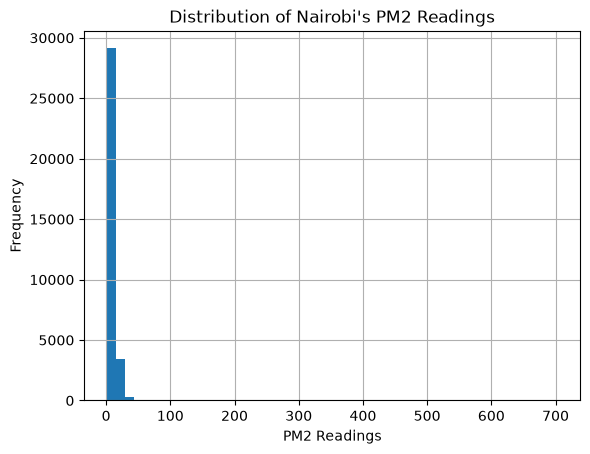

In [8]:
# Explore the distribution of PM2 
fig, ax=plt.subplots()
df["P2"].hist(ax=ax, bins=50)
plt.xlabel("PM2 Readings")
plt.ylabel("Frequency")
plt.title("Distribution of Nairobi's PM2 Readings");

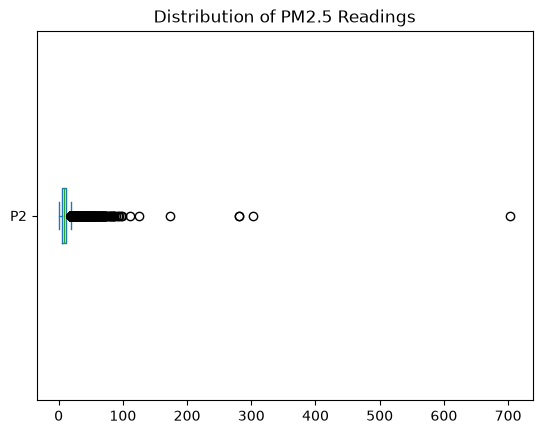

In [9]:
# Box plot
df_clean["P2"].plot(kind="box", 
    vert=False, 
    title="Distribution of PM2.5 Readings"
);

In [10]:
df_clean.describe()

,P2
count,32906.000000
mean,9.144093
std,7.708120
min,0.950000
25%,5.400000
50%,7.700000
75%,10.950000
max,703.200000


From the plots and summary statistics, it is clear that the distribution is right skewed with high end outliers that needs to be addressed before modelling

<Axes: title={'center': 'PM2.5 Time Series'}, xlabel='Time', ylabel='PM2.5'>

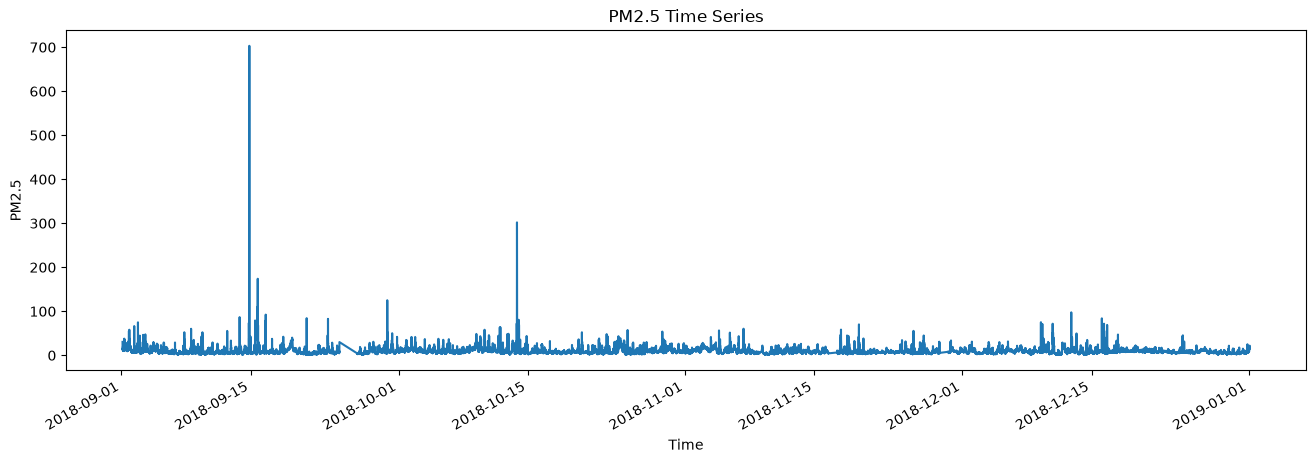

In [12]:
fig, ax=plt.subplots(figsize=(16,5))
df["P2"].plot(ylabel="PM2.5", xlabel="Time", title="PM2.5 Time Series",ax=ax)

In [13]:
# Resample readings to hourly windows and forwad fill null values
df=df["P2"].resample("1h").mean().ffill().to_frame()
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2928 entries, 2018-09-01 03:00:00+03:00 to 2019-01-01 02:00:00+03:00
Freq: h
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   P2      2928 non-null   float64
dtypes: float64(1)
memory usage: 45.8 KB


In [14]:
# Plot rolling averages
df["P2"].rolling(168).mean().head()

timestamp
2018-09-01 03:00:00+03:00   NaN
2018-09-01 04:00:00+03:00   NaN
2018-09-01 05:00:00+03:00   NaN
2018-09-01 06:00:00+03:00   NaN
2018-09-01 07:00:00+03:00   NaN
Freq: h, Name: P2, dtype: float64

<Axes: title={'center': 'Weekly Rolling Average'}, xlabel='Time', ylabel='PM2.5'>

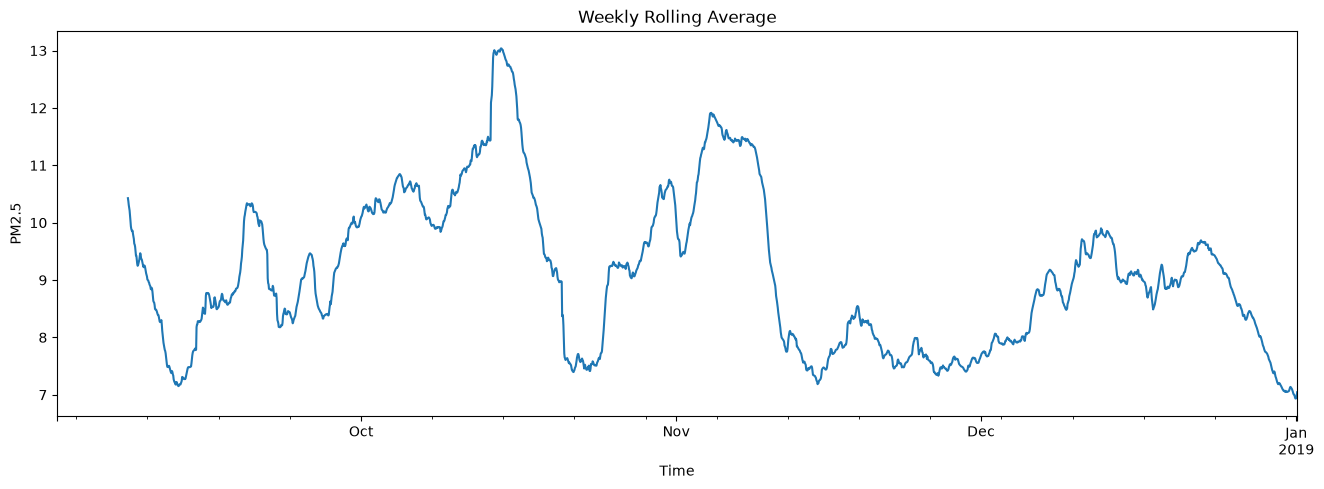

In [15]:
fig, ax=plt.subplots(figsize=(16, 5))
df["P2"].rolling(168).mean().plot(ax=ax, xlabel="Time", ylabel="PM2.5", title="Weekly Rolling Average")

In [16]:
# Add lag feature
df["P2.L1"]=df["P2"].shift(1)
df=df.dropna()
df.head()

,P2,P2.L1
timestamp,,
2018-09-01 04:00:00+03:00,15.800000,16.006364
2018-09-01 05:00:00+03:00,11.420000,15.800000
2018-09-01 06:00:00+03:00,11.614167,11.420000
2018-09-01 07:00:00+03:00,17.665000,11.614167
2018-09-01 08:00:00+03:00,21.016667,17.665000


In [17]:
df.corr()

,P2,P2.L1
P2,1.00000,0.62987
P2.L1,0.62987,1.00000


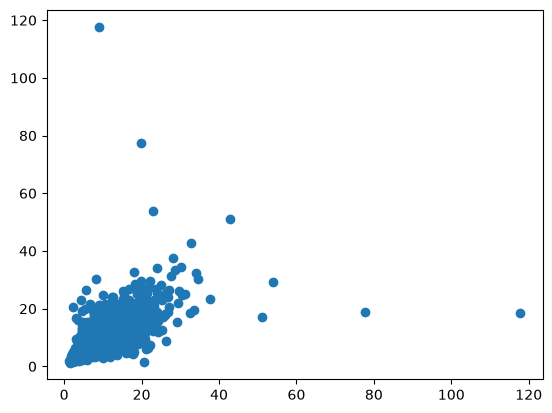

In [18]:
plt.scatter(x=df["P2.L1"], y=df["P2"])

In [19]:
# Split
features=["P2.L1"]
target="P2"
X=df[features]
y=df[target]

In [20]:
# Train test split(Time Series Case)
cutoff=int(len(df)*0.8)
X_train, y_train=X.iloc[:cutoff],y.iloc[:cutoff]
X_test, y_test=X.iloc[cutoff:],y.iloc[cutoff:]

In [21]:
# Build Model
# Baseline
y_mean=y.mean()
y_pred_baseline=[y_mean]*len(y)
mae_baseline=mean_absolute_error(y, y_pred_baseline)
print(f"y mean: {y_mean}")
print(f"MAE baseline: {mae_baseline}")

y mean: 9.12718706517451
MAE baseline: 3.677230313468186


In [22]:
model=LinearRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
y_pred_train=model.predict(X_train)
train_mae=mean_absolute_error(y_train, y_pred_train)
model_mae=mean_absolute_error(y_test, y_pred)
print(f"Train MAE: {train_mae}")
print(f"Model MAE: {model_mae}")

Train MAE: 2.5274487034307542
Model MAE: 1.8318538928852923


In [23]:
# Communicate
intercept=model.intercept_
coefficient=model.coef_
print(f"P2={intercept} + {coefficient}*P2.L1")

P2=3.574555514611192 + [0.61535045]*P2.L1


<Axes: xlabel='timestamp'>

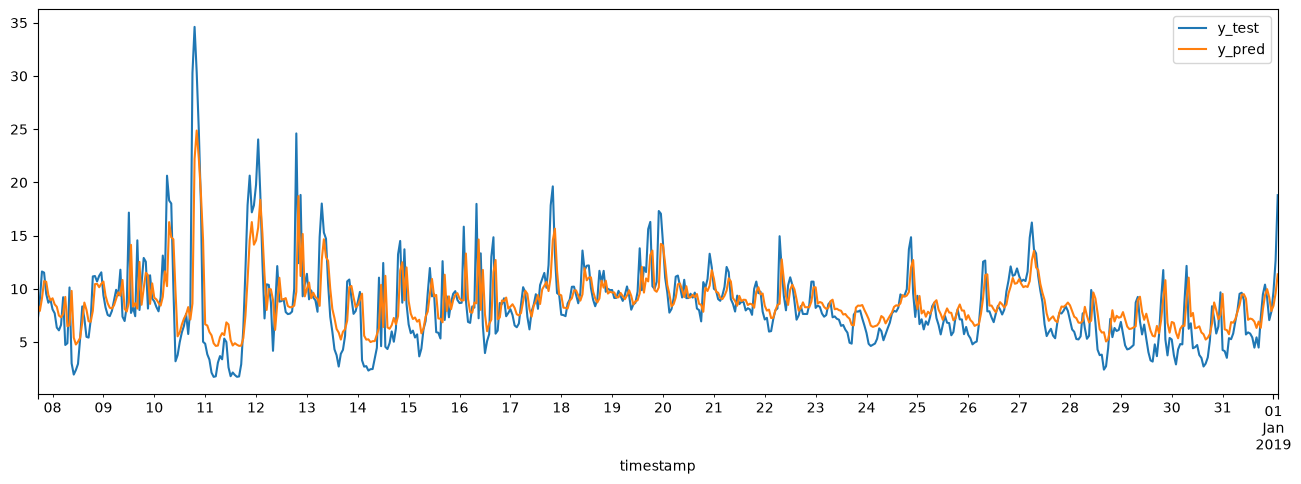

In [24]:
df_pred_test=pd.DataFrame(
    {
        "y_test":y_test,
        "y_pred":model.predict(X_test)
    }
)
fig, ax=plt.subplots(figsize=(16,5))
df_pred_test.plot(kind="line", ax=ax)